# Splitwise: minimizando o número de transações

Dado o saldo de cada pessoa de um grupo (negativo para quem deve, positivo para quem tem a
receber, e soma total igual a zero), o problema consiste em liquidar todas as dívidas com o
menor número possível de transações.

O notebook está organizado na ordem de dependência do código: primeiro os auxiliares e as
estruturas de dados (instância e solução), depois os algoritmos construtivos ($AC_G$ e $AC_R$),
as buscas locais ($BL_{FI}$ e $BL_{BI}$), o executor do experimento e, por fim, a execução das
instâncias com os gráficos e a tabela de resultados.

## Preparação do ambiente

Instalação do `gdown`, usado para baixar as instâncias do Google Drive, e os imports de todo o
código que vem a seguir.

In [1]:
%pip install -q gdown

Note: you may need to restart the kernel to use updated packages.


In [2]:
from abc import ABC, abstractmethod
from concurrent.futures import ProcessPoolExecutor, as_completed
from dataclasses import dataclass
from datetime import datetime
from io import StringIO
from typing import (
    Any,
    Callable,
    Dict,
    FrozenSet,
    Iterator,
    List,
    NamedTuple,
    Optional,
    Protocol,
    Tuple,
)
import copy
import heapq
import json
import multiprocessing
import os
import sys
import time
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.io.formats.style import Styler

## Instâncias

As instâncias são baixadas da pasta pública do Google Drive. Cada arquivo tem duas colunas,
o índice da pessoa e o seu saldo. A pasta também contém um `.docx` com as regras de geração,
descartado pelo filtro de extensão. O download só acontece se a pasta local ainda não existir,
tanto para reexecutar a célula à vontade quanto para não esbarrar no limite de requisições do
Drive.

In [3]:
DRIVE_URL = 'https://drive.google.com/drive/folders/109ZP_ZRzfMuTwQC9Vv4e7dlkSuuiMHsm'
INSTANCES_DIR = 'instances'
INSTANCE_SUFFIX = '.txt'

if not os.path.isdir(INSTANCES_DIR):
    gdown.download_folder(DRIVE_URL, output=INSTANCES_DIR, quiet=True)

instance_paths = sorted(
    os.path.join(INSTANCES_DIR, name)
    for name in os.listdir(INSTANCES_DIR)
    if name.endswith(INSTANCE_SUFFIX)
)

print(f'{len(instance_paths)} instâncias em {INSTANCES_DIR}/')

32 instâncias em instances/


## `now`

Carimbo de data e hora usado nas mensagens de progresso da execução.

In [4]:
def now() -> str:
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

## `pair_direct_transactions`

Emparelha quem deve exatamente o que outra pessoa tem a receber: cada par desses se resolve com
uma única transação e sai da conta. Devolve as transações formadas e quem continua com saldo,
tudo como posições no vetor de saldos. É o ponto de partida de todos os algoritmos.

In [5]:
Pairing = Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]

def pair_direct_transactions(balances: np.ndarray) -> Pairing:
    receivers = np.flatnonzero(balances > 0)
    payers = np.flatnonzero(balances < 0)

    receiver_amounts = balances[receivers]
    payer_amounts = -balances[payers]

    receivers, receiver_amounts = _sort_by_amount(receivers, receiver_amounts)
    payers, payer_amounts = _sort_by_amount(payers, payer_amounts)

    matched_receivers = _rank_within_amount(receiver_amounts) < _count_at(
        payer_amounts, receiver_amounts
    )
    matched_payers = _rank_within_amount(payer_amounts) < _count_at(
        receiver_amounts, payer_amounts
    )

    remaining = np.concatenate((receivers[~matched_receivers], payers[~matched_payers]))

    return (
        payers[matched_payers],
        receivers[matched_receivers],
        receiver_amounts[matched_receivers],
        remaining,
    )

def _sort_by_amount(people: np.ndarray, amounts: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    order = np.argsort(amounts, kind='stable')

    return people[order], amounts[order]

def _rank_within_amount(amounts: np.ndarray) -> np.ndarray:
    if amounts.size == 0:
        return np.empty(0, dtype=np.int64)

    starts = np.flatnonzero(np.concatenate(([True], amounts[1:] != amounts[:-1])))
    counts = np.diff(np.append(starts, amounts.size))

    return np.arange(amounts.size) - np.repeat(starts, counts)

def _count_at(sorted_amounts: np.ndarray, wanted: np.ndarray) -> np.ndarray:
    return (
        np.searchsorted(sorted_amounts, wanted, side='right')
        - np.searchsorted(sorted_amounts, wanted, side='left')
    )

## `Instance`

Quanto cada pessoa deve ou tem a receber. Negativo é pagador, positivo é recebedor, e a soma
tem de ser zero.

In [6]:
@dataclass
class Instance:
    balances: np.ndarray
    name: str = ""

    def __post_init__(self) -> None:
        self.balances = np.asarray(self.balances, dtype=np.int64)

        if self.balances.sum() != 0:
            raise ValueError('balances must sum to zero')

## `InstanceReader`

Lê um arquivo de instância no formato de duas colunas, índice e saldo, que é o das instâncias
da disciplina.

In [7]:
class InstanceReader:
    def read_with_index(self, file_path: str) -> Instance:
        lines = self._load(file_path, ndmin=2)
        balances = lines[:, 1]

        return Instance(balances, name=self._instance_name(file_path))

    def _load(self, file_path: str, ndmin: int) -> np.ndarray:
        with open(file_path) as file:
            columns = file.read().replace(',', ' ')

        return np.loadtxt(StringIO(columns), dtype=np.int64, ndmin=ndmin)

    def _instance_name(self, file_path: str) -> str:
        return file_path.split('/')[-1].split('.')[0]

## `Solution`

As transações que liquidam uma instância, guardadas como três vetores paralelos (pagador,
recebedor e valor). O `fitness` é o número de transações e `validate` confere que os saldos
fecham exatamente.

In [8]:
@dataclass
class Solution:
    instance: Instance
    payers: np.ndarray
    receivers: np.ndarray
    amounts: np.ndarray

    def __post_init__(self) -> None:
        self.payers = np.asarray(self.payers, dtype=np.int64)
        self.receivers = np.asarray(self.receivers, dtype=np.int64)
        self.amounts = np.asarray(self.amounts)

    @property
    def people(self) -> int:
        return len(self.instance.balances)

    @property
    def fitness(self) -> int:
        return len(self.payers)

    def validate(self) -> None:
        if not (len(self.payers) == len(self.receivers) == len(self.amounts)):
            raise ValueError('payers, receivers and amounts must be the same length')

        unknown = (
            (self.payers < 0) | (self.payers >= self.people)
            | (self.receivers < 0) | (self.receivers >= self.people)
        )

        self._reject(unknown, 'refers to an unknown person')
        self._reject(self.payers == self.receivers, 'has the same payer and receiver')
        self._reject(self.amounts <= 0, 'must transfer a positive amount')

        net = np.zeros(self.people, dtype=self.amounts.dtype)

        np.add.at(net, self.payers, -self.amounts)
        np.add.at(net, self.receivers, self.amounts)

        if not np.array_equal(net, self.instance.balances):
            person = int(np.argmax(net != self.instance.balances))
            raise ValueError(
                f"person {person} settled {net[person]} instead of "
                f"{self.instance.balances[person]}"
            )

    def _reject(self, offending: np.ndarray, complaint: str) -> None:
        if not offending.any():
            return

        index = int(np.argmax(offending))

        raise ValueError(
            f"transaction ({self.payers[index]}, {self.receivers[index]}, "
            f"{self.amounts[index]}) {complaint}"
        )

## `RunResult`

O retorno de uma execução: a solução encontrada e quantas iterações foram gastas (só as buscas
locais preenchem a segunda).

In [9]:
@dataclass
class RunResult:
    solution: Solution
    iterations: Optional[int] = None

## `BaseAlgorithm`

Contrato comum a todos os algoritmos: um nome, que dá origem ao nome das colunas do relatório,
uma execução e as métricas medidas.

In [10]:
METRICS = [
    'fitness',
    'seconds',
]

class BaseAlgorithm(ABC):
    @abstractmethod
    def name(self) -> str:
        pass

    @abstractmethod
    def run(self, instance: Instance) -> RunResult:
        pass

    def supports(self, instance: Instance) -> bool:
        return True

    def metrics(self) -> List[str]:
        return METRICS

## `RandomKeys`

Uma chave aleatória por pessoa e a ordem que essas chaves impõem sobre um subconjunto de
pessoas. É a codificação *random-key* compartilhada pelos dois construtivos, o que permite
entregar exatamente o mesmo cromossomo aos dois.

In [11]:
class RandomKeys:
    def __init__(self, seed: Optional[int] = None) -> None:
        self._rng = np.random.default_rng(seed)
        self._keys: Optional[np.ndarray] = None

    @property
    def keys(self) -> Optional[np.ndarray]:
        return self._keys

    def set(self, keys: Optional[np.ndarray]) -> None:
        if keys is None:
            self._keys = None

            return

        chromosome = np.asarray(keys, dtype=np.float64)

        if chromosome.ndim != 1:
            raise ValueError('random_keys must be one-dimensional')

        if chromosome.size and (chromosome.min() < 0.0 or chromosome.max() > 1.0):
            raise ValueError('random_keys must lie between 0 and 1')

        self._keys = chromosome

    def fits(self, people: int) -> bool:
        return self._keys is None or len(self._keys) == people

    def order(self, people: int, subset: np.ndarray) -> np.ndarray:
        keys = self._keys_for(people)

        return subset[np.argsort(keys[subset], kind='stable')]

    def _keys_for(self, people: int) -> np.ndarray:
        if self._keys is None:
            return self._rng.random(people)

        if len(self._keys) != people:
            raise ValueError(
                f"{len(self._keys)} random keys cannot decode an instance of "
                f"{people} people"
            )

        return self._keys

## `GreedyAlgorithm` — algoritmo construtivo guloso ($AC_G$)

Liquida todo mundo numa única passada: depois de emparelhar os valores exatamente iguais,
casa repetidamente o maior devedor com o maior credor. `count_largest_first` conta as
transações dessa mesma regra sem construí-las, e é o que a busca local usa para pontuar
vizinhos. `construct` devolve também uma ordem, para servir de ponto de partida à busca local.

In [12]:
Transactions = Tuple[np.ndarray, np.ndarray, np.ndarray]

class GreedyAlgorithm(BaseAlgorithm):
    def __init__(self, seed: Optional[int] = None) -> None:
        self._keys = RandomKeys(seed)

    def name(self) -> str:
        return 'greedy'

    @property
    def random_keys(self) -> Optional[np.ndarray]:
        return self._keys.keys

    def set_random_keys(self, random_keys: Optional[np.ndarray]) -> None:
        self._keys.set(random_keys)

    def supports(self, instance: Instance) -> bool:
        return self._keys.fits(len(instance.balances))

    def run(self, instance: Instance) -> RunResult:
        return RunResult(solution=self._settle(instance))

    def construct(self, instance: Instance) -> Tuple[np.ndarray, Solution]:
        balances = instance.balances

        _, _, _, left = pair_direct_transactions(balances)

        return self._keys.order(len(balances), left), self._settle(instance)

    def _settle(self, instance: Instance) -> Solution:
        payers, receivers, amounts = self.settle(
            np.arange(len(instance.balances)), instance.balances
        )

        return Solution(
            instance=instance,
            payers=payers,
            receivers=receivers,
            amounts=amounts,
        )

    def settle(self, people: np.ndarray, balances: np.ndarray) -> Transactions:
        paired_payers, paired_receivers, paired_amounts, left = pair_direct_transactions(balances)

        heap_payers, heap_receivers, heap_amounts = self.settle_largest_first(
            left, balances[left]
        )

        return (
            people[np.concatenate((paired_payers, heap_payers))],
            people[np.concatenate((paired_receivers, heap_receivers))],
            np.concatenate((paired_amounts, heap_amounts)),
        )

    def settle_largest_first(self, positions: np.ndarray, balances: np.ndarray) -> Transactions:
        owed = balances.tolist()
        people = positions.tolist()

        payers = [(balance, person) for person, balance in zip(people, owed) if balance < 0]
        receivers = [(-balance, person) for person, balance in zip(people, owed) if balance > 0]

        heapq.heapify(payers)
        heapq.heapify(receivers)

        settled_payers: List[int] = []
        settled_receivers: List[int] = []
        settled_amounts: List[int] = []

        while payers and receivers:
            owes, payer = heapq.heappop(payers)
            due, receiver = heapq.heappop(receivers)

            owes = -owes
            due = -due
            amount = min(owes, due)

            settled_payers.append(payer)
            settled_receivers.append(receiver)
            settled_amounts.append(amount)

            if owes > due:
                heapq.heappush(payers, (-(owes - due), payer))
            elif owes < due:
                heapq.heappush(receivers, (-(due - owes), receiver))

        return (
            np.array(settled_payers, dtype=np.int64),
            np.array(settled_receivers, dtype=np.int64),
            np.array(settled_amounts, dtype=np.int64),
        )

    def count_largest_first(self, balances: List[int]) -> int:
        payers = [balance for balance in balances if balance < 0]
        receivers = [-balance for balance in balances if balance > 0]

        heapq.heapify(payers)
        heapq.heapify(receivers)

        count = 0

        while payers and receivers:
            owes = -heapq.heappop(payers)
            due = -heapq.heappop(receivers)

            count += 1

            if owes > due:
                heapq.heappush(payers, -(owes - due))
            elif owes < due:
                heapq.heappush(receivers, -(due - owes))

        return count

## `ZeroSumScan`

Divide as pessoas, na ordem em que são adicionadas, em grupos cujos saldos somam zero: sempre
que o total acumulado se repete, um grupo se fecha. Feito como objeto, e não como função, para
que a busca local possa pausar a varredura num prefixo e restaurá-la a cada vizinho.

In [13]:
State = Tuple[List[int], Dict[int, int], List[Tuple[int, int]], int]

class ZeroSumScan:
    def __init__(self, balances: np.ndarray) -> None:
        self._balances = balances.tolist()

        self.reset()

    def reset(self) -> None:
        self._pending: List[int] = []
        self._opened_at: Dict[int, int] = {0: 0}
        self._history: List[Tuple[int, int]] = [(0, 0)]
        self._running = 0

    def add(self, person: int) -> Optional[List[int]]:
        self._running += self._balances[person]
        self._pending.append(person)

        if self._running in self._opened_at:
            at = self._opened_at[self._running]

            group = self._pending[at:]
            del self._pending[at:]

            while self._history[-1][1] > at:
                stale, _ = self._history.pop()
                del self._opened_at[stale]

            return group

        self._opened_at[self._running] = len(self._pending)
        self._history.append((self._running, len(self._pending)))

        return None

    def snapshot(self) -> State:
        return (
            self._pending.copy(),
            self._opened_at.copy(),
            self._history.copy(),
            self._running,
        )

    def restore(self, state: State) -> None:
        pending, opened_at, history, running = state

        self._pending = pending.copy()
        self._opened_at = opened_at.copy()
        self._history = history.copy()
        self._running = running

## `PermutationDecoder`

Transforma uma ordem de pessoas na solução que ela implica: corta a ordem em grupos de soma
zero e resolve cada grupo com o guloso. Como um grupo de $m$ pessoas custa no máximo $m - 1$
transações, $k$ grupos limitam a solução a $N - k$ — é o número de cortes que a busca sobre
ordens realmente persegue.

In [14]:
class PermutationDecoder:
    def __init__(self) -> None:
        self._greedy = GreedyAlgorithm()

    def survivors(self, balances: np.ndarray) -> np.ndarray:
        _, _, _, left = pair_direct_transactions(balances)

        return left

    def decode(self, instance: Instance, order: np.ndarray) -> Solution:
        balances = instance.balances

        paired_payers, paired_receivers, paired_amounts, _ = pair_direct_transactions(balances)

        payers: List[np.ndarray] = [paired_payers]
        receivers: List[np.ndarray] = [paired_receivers]
        amounts: List[np.ndarray] = [paired_amounts]

        for group in self.zero_sum_groups(balances, order):
            group_payers, group_receivers, group_amounts = self._greedy.settle_largest_first(
                group, balances[group]
            )

            payers.append(group_payers)
            receivers.append(group_receivers)
            amounts.append(group_amounts)

        return Solution(
            instance=instance,
            payers=np.concatenate(payers),
            receivers=np.concatenate(receivers),
            amounts=np.concatenate(amounts),
        )

    def zero_sum_groups(self, balances: np.ndarray, order: np.ndarray) -> List[np.ndarray]:
        scan = ZeroSumScan(balances)
        groups: List[np.ndarray] = []

        for person in order.tolist():
            group = scan.add(person)

            if group is not None:
                groups.append(np.array(group, dtype=np.int64))

        return groups

## `PermutationConstructor`

O protocolo que a busca local espera de um construtivo: produzir uma ordem e uma solução de
partida. Tanto o $AC_G$ quanto o $AC_R$ o satisfazem.

In [15]:
class PermutationConstructor(Protocol):
    def construct(self, instance: Instance) -> Tuple[np.ndarray, Solution]:
        ...

    def supports(self, instance: Instance) -> bool:
        ...

    def name(self) -> str:
        ...

## `RandomKeyAlgorithm` — algoritmo construtivo randomizado ($AC_R$)

Sorteia uma chave por pessoa, ordena os sobreviventes por essas chaves e decodifica a ordem
resultante. Só as pessoas que sobraram do emparelhamento são ordenadas: as demais são
liquidadas do mesmo jeito qualquer que seja a ordem.

In [16]:
class RandomKeyAlgorithm(BaseAlgorithm):
    def __init__(self, seed: Optional[int] = None) -> None:
        self._decoder = PermutationDecoder()
        self._keys = RandomKeys(seed)

    def name(self) -> str:
        return 'random_key'

    @property
    def random_keys(self) -> Optional[np.ndarray]:
        return self._keys.keys

    def set_random_keys(self, random_keys: Optional[np.ndarray]) -> None:
        self._keys.set(random_keys)

    def supports(self, instance: Instance) -> bool:
        return self._keys.fits(len(instance.balances))

    def run(self, instance: Instance) -> RunResult:
        _, solution = self.construct(instance)

        return RunResult(solution=solution)

    def construct(self, instance: Instance) -> Tuple[np.ndarray, Solution]:
        balances = instance.balances
        order = self._keys.order(len(balances), self._decoder.survivors(balances))

        return order, self._decoder.decode(instance, order)

## `OrderEvaluator`

Pontua ordens devolvendo apenas o número de transações, sem construir solução alguma. Guarda
o custo de cada grupo já visto (o custo depende do conjunto, não da ordem interna) e permite
retomar a varredura de um prefixo, o que é o que torna viável percorrer uma vizinhança de
$O(n^2)$ trocas.

In [17]:
Prefix = Tuple[State, int]

class OrderEvaluator:
    def __init__(self, instance: Instance) -> None:
        balances = instance.balances

        paired_payers, _, _, _ = pair_direct_transactions(balances)

        self._pairs = len(paired_payers)
        self._balances = balances.tolist()
        self._greedy = GreedyAlgorithm()
        self._scan = ZeroSumScan(balances)
        self._costs: Dict[FrozenSet[int], int] = {}

    @property
    def balances(self) -> List[int]:
        return self._balances

    def prefixes(self, order: List[int]) -> List[Prefix]:
        self._scan.reset()

        cost = 0
        prefixes: List[Prefix] = [(self._scan.snapshot(), cost)]

        for person in order[:-2]:
            group = self._scan.add(person)

            if group is not None:
                cost += self._cost(group)

            prefixes.append((self._scan.snapshot(), cost))

        return prefixes

    def fitness_from(self, prefix: Prefix, order: List[int], i: int, j: int) -> int:
        state, cost = prefix

        self._scan.restore(state)

        tail = order[i:]
        tail[0] = order[j]
        tail[j - i] = order[i]

        return self._pairs + cost + self._closed(tail)

    def _closed(self, people: List[int]) -> int:
        scan = self._scan
        cost = 0

        for person in people:
            group = scan.add(person)

            if group is not None:
                cost += self._cost(group)

        return cost

    def _cost(self, group: List[int]) -> int:
        key = frozenset(group)
        cost = self._costs.get(key)

        if cost is None:
            balances = self._balances
            cost = self._greedy.count_largest_first([balances[person] for person in group])
            self._costs[key] = cost

        return cost

## `LocalSearchAlgorithm`

Busca local sobre ordens: a vizinhança é toda troca de posições $(i, j)$, com $i < j$. O laço
externo — o que o $N_{It}$ da tabela conta — repete-se enquanto algum vizinho melhorar o
incumbente. Qual vizinho aceitar é a única decisão delegada às subclasses, e o construtivo que
fornece o ponto de partida é injetado, o que também dá nome ao algoritmo.

In [18]:
MAX_PEOPLE = None

Step = Tuple[List[int], int]

class LocalSearchAlgorithm(BaseAlgorithm, ABC):
    def __init__(self, constructor: PermutationConstructor) -> None:
        self._constructor = constructor
        self._decoder = PermutationDecoder()

    @property
    def constructor(self) -> PermutationConstructor:
        return self._constructor

    def set_constructor(self, constructor: PermutationConstructor) -> None:
        self._constructor = constructor

    def name(self) -> str:
        return f"{self._constructor.name()}_{self.suffix()}"

    @abstractmethod
    def suffix(self) -> str:
        pass

    def supports(self, instance: Instance) -> bool:
        return (
            MAX_PEOPLE is None or len(instance.balances) <= MAX_PEOPLE
            and self._constructor.supports(instance)
        )

    def metrics(self) -> List[str]:
        return METRICS + ['iterations']

    def run(self, instance: Instance) -> RunResult:
        order, solution = self._constructor.construct(instance)
        _, iterations, improved = self.improve(order, solution)

        return RunResult(solution=improved, iterations=iterations)

    def improve(self, order: np.ndarray, solution: Solution) -> Tuple[np.ndarray, int, Solution]:
        instance = solution.instance
        positions = order.tolist()
        fitness = solution.fitness

        evaluator = OrderEvaluator(instance)

        moved = False
        iterations = 0

        while True:
            accepted = self._accept(evaluator, positions, fitness)
            iterations += 1

            if accepted is None:
                break

            positions, fitness = accepted
            moved = True

        if not moved:
            return order, iterations, solution

        order = np.array(positions, dtype=np.int64)

        return order, iterations, self._decoder.decode(instance, order)

    @abstractmethod
    def _accept(
        self,
        evaluator: OrderEvaluator,
        order: List[int],
        fitness: int,
    ) -> Optional[Step]:
        pass

    def _swap(self, order: List[int], i: int, j: int) -> List[int]:
        swapped = order.copy()
        swapped[i], swapped[j] = swapped[j], swapped[i]

        return swapped

## `FirstImprovementAlgorithm` — busca local FI ($BL_{FI}$)

Move-se para o primeiro vizinho que melhora o incumbente, parando a varredura ali mesmo. Cada
passo é barato enquanto há ganhos; só um ótimo local custa a vizinhança inteira.

In [19]:
class FirstImprovementAlgorithm(LocalSearchAlgorithm):
    def suffix(self) -> str:
        return 'fi'

    def _accept(
        self,
        evaluator: OrderEvaluator,
        order: List[int],
        fitness: int,
    ) -> Optional[Step]:
        positions = len(order)

        prefixes = evaluator.prefixes(order)
        balances = evaluator.balances

        for i in range(positions - 1):
            prefix = prefixes[i]
            balance = balances[order[i]]

            for j in range(i + 1, positions):
                if balances[order[j]] == balance:
                    continue

                candidate_fitness = evaluator.fitness_from(prefix, order, i, j)

                if candidate_fitness < fitness:
                    return self._swap(order, i, j), candidate_fitness

        return None

## `BestImprovementAlgorithm` — busca local BI ($BL_{BI}$)

Varre toda a vizinhança e move-se para o melhor vizinho. Cada passo custa os $O(n^2)$ vizinhos
inteiros, mas desce pela direção mais íngreme disponível — menos passos, e melhores.

In [20]:
class BestImprovementAlgorithm(LocalSearchAlgorithm):
    def suffix(self) -> str:
        return 'bi'

    def _accept(
        self,
        evaluator: OrderEvaluator,
        order: List[int],
        fitness: int,
    ) -> Optional[Step]:
        positions = len(order)
        prefixes = evaluator.prefixes(order)
        balances = evaluator.balances

        best: Optional[Tuple[int, int]] = None
        best_fitness = fitness

        for i in range(positions - 1):
            prefix = prefixes[i]
            balance = balances[order[i]]

            for j in range(i + 1, positions):
                if balances[order[j]] == balance:
                    continue

                candidate_fitness = evaluator.fitness_from(prefix, order, i, j)

                if candidate_fitness < best_fitness:
                    best_fitness = candidate_fitness
                    best = (i, j)

        if best is None:
            return None

        return self._swap(order, *best), best_fitness

## `Runner`

Executa cada par (instância, algoritmo), cronometra, valida a solução devolvida e monta uma
linha por instância com todas as métricas. No notebook ele é chamado com `max_workers=1`: o
`ProcessPoolExecutor` usa o método `spawn`, que não consegue serializar classes definidas
dentro do próprio notebook — e, como cada execução trabalha sobre uma cópia do algoritmo, os
números medidos são exatamente os mesmos de qualquer outro número de processos.

In [21]:
Row = Dict[str, Any]

START_METHOD = 'spawn'

class Task(NamedTuple):
    index: int
    instance: Instance
    algorithm: BaseAlgorithm

class Runner:
    def run(
        self,
        instances: List[Instance],
        algorithms: List[BaseAlgorithm],
        output_path: Optional[str] = None,
        max_workers: Optional[int] = None,
    ) -> pd.DataFrame:
        workers = self._workers(max_workers, len(instances) * len(algorithms))
        tasks = self._tasks(instances, algorithms, ordered=workers == 1)

        rows = [self._skeleton(instance, algorithms) for instance in instances]

        remaining = [len(algorithms)] * len(instances)

        print(f'[{now()}] Starting {len(tasks)} runs on {workers} worker(s)')
        print()

        started = time.perf_counter()

        for done, (task, measured) in enumerate(self._results(tasks, workers), start=1):
            rows[task.index].update(measured)
            remaining[task.index] -= 1

            print(self._progress(task, measured, done, len(tasks)))

            if remaining[task.index] == 0:
                self._save(self._finished(rows, remaining), output_path)

        print()
        print(f'[{now()}] Finished all runs in {time.perf_counter() - started:.1f}s')

        return pd.DataFrame(rows, columns=self._columns(algorithms))

    def _workers(self, max_workers: Optional[int], tasks: int) -> int:
        if max_workers is not None:
            if max_workers < 1:
                raise ValueError('max_workers must be at least 1')

            return max(1, min(max_workers, tasks))

        available = (
            len(os.sched_getaffinity(0))
            if hasattr(os, 'sched_getaffinity')
            else os.cpu_count() or 1
        )

        return max(1, min(available, tasks))

    def _tasks(
        self,
        instances: List[Instance],
        algorithms: List[BaseAlgorithm],
        ordered: bool,
    ) -> List[Task]:
        tasks = [
            Task(index, instance, algorithm)
            for index, instance in enumerate(instances)
            for algorithm in algorithms
        ]

        if ordered:
            return tasks

        return sorted(tasks, key=lambda task: -len(task.instance.balances))

    def _results(self, tasks: List[Task], workers: int) -> Iterator[Tuple[Task, Row]]:
        if workers == 1:
            for task in tasks:
                yield task, self._execute(task.instance, task.algorithm)

            return

        with ProcessPoolExecutor(
            max_workers=workers,
            mp_context=multiprocessing.get_context(START_METHOD),
        ) as executor:
            futures = {
                executor.submit(self._execute, task.instance, task.algorithm): task
                for task in tasks
            }

            try:
                for future in as_completed(futures):
                    yield futures[future], future.result()
            except BaseException:
                executor.shutdown(wait=True, cancel_futures=True)

                raise

    def _skeleton(self, instance: Instance, algorithms: List[BaseAlgorithm]) -> Row:
        row: Row = {column: None for column in self._columns(algorithms)}

        row['n'] = len(instance.balances)
        row['instance'] = instance.name

        return row

    def _finished(self, rows: List[Row], remaining: List[int]) -> List[Row]:
        return [row for row, left in zip(rows, remaining) if left == 0]

    def _progress(self, task: Task, measured: Row, done: int, total: int) -> str:
        name = task.algorithm.name()
        fitness = measured.get(f'{name}_fitness')
        seconds = measured.get(f'{name}_seconds')

        if seconds is None:
            detail = 'unsupported'
        elif fitness is None:
            detail = f'failed after {seconds:.3f}s'
        else:
            detail = f'fitness {fitness} in {seconds:.3f}s'

        return f'[{now()}] ({done}/{total}) {task.instance.name} - {name}: {detail}'

    def _save(self, rows: List[Row], output_path: Optional[str]) -> None:
        if output_path is None:
            return

        directory = os.path.dirname(output_path)

        if directory:
            os.makedirs(directory, exist_ok=True)

        temporary = f'{output_path}.tmp'

        with open(temporary, 'w') as file:
            json.dump(rows, file, indent=2)

        os.replace(temporary, output_path)

    def _columns(self, algorithms: List[BaseAlgorithm]) -> List[str]:
        return ['n', 'instance'] + [
            f"{algorithm.name()}_{metric}"
            for algorithm in algorithms
            for metric in algorithm.metrics()
        ]

    def _execute(self, instance: Instance, algorithm: BaseAlgorithm) -> Row:
        algorithm = copy.deepcopy(algorithm)
        name = algorithm.name()

        if not algorithm.supports(instance):
            return self._metrics(algorithm)

        started = time.perf_counter()

        try:
            result = algorithm.run(instance)
        except Exception as error:
            print(
                f"{name} failed on {len(instance.balances)} people: {error}",
                file=sys.stderr,
            )

            return self._metrics(algorithm, seconds=time.perf_counter() - started)

        seconds = time.perf_counter() - started

        result.solution.validate()

        return self._metrics(algorithm, seconds=seconds, result=result)

    def _metrics(
        self,
        algorithm: BaseAlgorithm,
        seconds: Optional[float] = None,
        result: Optional[RunResult] = None,
    ) -> Row:
        measured = {
            'fitness': result.solution.fitness if result is not None else None,
            'seconds': seconds,
            'iterations': result.iterations if result is not None else None,
        }

        return {
            f'{algorithm.name()}_{metric}': measured[metric]
            for metric in algorithm.metrics()
        }

## `Analysis`

Os gráficos e a tabela. `plot_results` desenha um ponto por instância para cada coluna pedida,
num eixo x categórico — instâncias distintas compartilham o mesmo $n$, e um eixo numérico as
empilharia. `results_table` monta a tabela no padrão pedido no enunciado, e `highlight_best`
destaca em negrito o melhor $sol$ de cada linha entre os quatro algoritmos de busca local.

In [22]:
Row = Dict[str, Any]

MARKERS = ('o', 's', '^', 'D', 'v', 'P', 'X', '*')

TABLE_COLUMNS = {
    'AC_G': {
        'sol': 'greedy_fitness',
        't(s)': 'greedy_seconds',
    },
    'AC_R': {
        'sol': 'random_key_fitness',
        't(s)': 'random_key_seconds',
    },
    'BL_FI(AC_G)': {
        'sol': 'greedy_fi_fitness',
        'N_It': 'greedy_fi_iterations',
        't(s)': 'greedy_fi_seconds',
    },
    'BL_FI(AC_R)': {
        'sol': 'random_key_fi_fitness',
        'N_It': 'random_key_fi_iterations',
        't(s)': 'random_key_fi_seconds',
    },
    'BL_BI(AC_G)': {
        'sol': 'greedy_bi_fitness',
        'N_It': 'greedy_bi_iterations',
        't(s)': 'greedy_bi_seconds',
    },
    'BL_BI(AC_R)': {
        'sol': 'random_key_bi_fitness',
        'N_It': 'random_key_bi_iterations',
        't(s)': 'random_key_bi_seconds',
    },
}

LOCAL_SEARCH_GROUPS = ('BL_FI(AC_G)', 'BL_FI(AC_R)', 'BL_BI(AC_G)', 'BL_BI(AC_R)')

BEST_COLUMNS = [(group, 'sol') for group in LOCAL_SEARCH_GROUPS]

SECONDS_COLUMNS = [(group, 't(s)') for group in TABLE_COLUMNS]

SECONDS_FORMAT = '{:.3f}'

SECONDS_DECIMALS = 3

BOLD = 'font-weight: bold'

class Analysis:
    def plot_results(
        self,
        rows: List[Row],
        columns: Dict[str, str],
        title: str,
        y_label: Optional[str] = None,
        log_scale: bool = False,
        format_instance: Optional[Callable[[str], str]] = None,
    ) -> None:
        ordered = self._ordered(rows)
        positions = range(len(ordered))
        labels = [self._label(row, format_instance) for row in ordered]

        figure, axes = plt.subplots(figsize=(10, 6))

        for index, (column, legend) in enumerate(columns.items()):
            axes.scatter(
                positions,
                self._values(ordered, column),
                label=legend,
                marker=MARKERS[index % len(MARKERS)],
                alpha=0.8,
            )

        axes.set_title(title)
        axes.set_xlabel('Instance')

        if y_label is not None:
            axes.set_ylabel(y_label)

        if log_scale:
            axes.set_yscale('log')

        axes.set_xticks(list(positions), labels, rotation=45, ha='right')
        axes.grid(axis='y', alpha=0.3)
        axes.legend()

        figure.tight_layout()

        plt.show()

    def results_table(
        self,
        rows: List[Row],
        format_instance: Optional[Callable[[str], str]] = None,
    ) -> pd.DataFrame:
        ordered = self._ordered(rows)

        table = pd.DataFrame(
            {
                (group, metric): [row.get(column) for row in ordered]
                for group, metrics in TABLE_COLUMNS.items()
                for metric, column in metrics.items()
            },
            index=pd.Index(
                [self._label(row, format_instance) for row in ordered], name='I'
            ),
        )

        table.columns = pd.MultiIndex.from_tuples(table.columns)

        return table.round(SECONDS_DECIMALS)

    def highlight_best(self, table: pd.DataFrame) -> Styler:
        return (
            table.style
            .format(SECONDS_FORMAT, subset=SECONDS_COLUMNS)
            .apply(self._best, axis=1, subset=BEST_COLUMNS)
        )

    def _best(self, row: pd.Series) -> List[str]:
        best = row.min()

        return [BOLD if value == best else '' for value in row]

    def _ordered(self, rows: List[Row]) -> List[Row]:
        return sorted(rows, key=lambda row: (row['n'], row['instance']))

    def _label(self, row: Row, format_instance: Optional[Callable[[str], str]]) -> str:
        name = row['instance']

        return name if format_instance is None else format_instance(name)

    def _values(self, rows: List[Row], column: str) -> List[float|int]:
        if not any(column in row for row in rows):
            raise ValueError(f"no result has a column named '{column}'")

        return [float('nan') if row.get(column) is None else int(row[column]) for row in rows]

## Execução das instâncias

As instâncias baixadas são lidas e filtradas por tamanho: `MAX_N = 200` mantém a execução em
torno de um minuto e meio. Com `MAX_N = None` as 32 instâncias são executadas, o que leva cerca
de 19 horas em um único processo — as instâncias de 900 a 1500 pessoas respondem sozinhas por
mais da metade desse tempo.

In [23]:
SEED = 42
MAX_N = 200

instance_reader = InstanceReader()

instances = [instance_reader.read_with_index(path) for path in instance_paths]
instances = [
    instance for instance in instances
    if MAX_N is None or len(instance.balances) <= MAX_N
]

print(f'{len(instances)} instâncias selecionadas')

12 instâncias selecionadas


Os seis algoritmos da tabela: os dois construtivos e as quatro combinações de busca local,
cada uma partindo de um deles. Todos compartilham a mesma semente, de modo que o cromossomo
deixa de ser uma variável entre eles.

In [24]:
algorithms = [
    GreedyAlgorithm(),
    RandomKeyAlgorithm(seed=SEED),
    BestImprovementAlgorithm(RandomKeyAlgorithm(seed=SEED)),
    FirstImprovementAlgorithm(RandomKeyAlgorithm(seed=SEED)),
    BestImprovementAlgorithm(GreedyAlgorithm(seed=SEED)),
    FirstImprovementAlgorithm(GreedyAlgorithm(seed=SEED)),
]

results = Runner().run(instances, algorithms, max_workers=1)

rows = results.to_dict('records')

[2026-09-22 23:20:43] Starting 72 runs on 1 worker(s)

[2026-09-22 23:20:43] (1/72) instancia_splitwise_100 - greedy: fitness 77 in 0.000s
[2026-09-22 23:20:43] (2/72) instancia_splitwise_100 - random_key: fitness 82 in 0.000s


[2026-09-22 23:20:43] (3/72) instancia_splitwise_100 - random_key_bi: fitness 76 in 0.197s


[2026-09-22 23:20:43] (4/72) instancia_splitwise_100 - random_key_fi: fitness 74 in 0.087s
[2026-09-22 23:20:43] (5/72) instancia_splitwise_100 - greedy_bi: fitness 77 in 0.093s


[2026-09-22 23:20:43] (6/72) instancia_splitwise_100 - greedy_fi: fitness 77 in 0.066s
[2026-09-22 23:20:43] (7/72) instancia_splitwise_100_20 - greedy: fitness 74 in 0.000s
[2026-09-22 23:20:43] (8/72) instancia_splitwise_100_20 - random_key: fitness 74 in 0.000s
[2026-09-22 23:20:43] (9/72) instancia_splitwise_100_20 - random_key_bi: fitness 69 in 0.032s


[2026-09-22 23:20:43] (10/72) instancia_splitwise_100_20 - random_key_fi: fitness 67 in 0.033s
[2026-09-22 23:20:43] (11/72) instancia_splitwise_100_20 - greedy_bi: fitness 69 in 0.032s
[2026-09-22 23:20:43] (12/72) instancia_splitwise_100_20 - greedy_fi: fitness 67 in 0.032s
[2026-09-22 23:20:43] (13/72) instancia_splitwise_150 - greedy: fitness 119 in 0.000s
[2026-09-22 23:20:43] (14/72) instancia_splitwise_150 - random_key: fitness 119 in 0.000s


...

[2026-09-22 23:20:56] (41/72) instancia_splitwise_200_8 - greedy_bi: fitness 131 in 0.551s


[2026-09-22 23:20:56] (42/72) instancia_splitwise_200_8 - greedy_fi: fitness 131 in 0.344s
[2026-09-22 23:20:56] (43/72) instancia_splitwise_200_80 - greedy: fitness 144 in 0.000s
[2026-09-22 23:20:56] (44/72) instancia_splitwise_200_80 - random_key: fitness 144 in 0.000s


[2026-09-22 23:20:57] (45/72) instancia_splitwise_200_80 - random_key_bi: fitness 138 in 0.267s
[2026-09-22 23:20:57] (46/72) instancia_splitwise_200_80 - random_key_fi: fitness 139 in 0.082s


[2026-09-22 23:20:57] (47/72) instancia_splitwise_200_80 - greedy_bi: fitness 138 in 0.266s
[2026-09-22 23:20:57] (48/72) instancia_splitwise_200_80 - greedy_fi: fitness 139 in 0.081s
[2026-09-22 23:20:57] (49/72) instancia_splitwise_30 - greedy: fitness 23 in 0.000s
[2026-09-22 23:20:57] (50/72) instancia_splitwise_30 - random_key: fitness 23 in 0.000s
[2026-09-22 23:20:57] (51/72) instancia_splitwise_30 - random_key_bi: fitness 22 in 0.004s
[2026-09-22 23:20:57] (52/72) instancia_splitwise_30 - random_key_fi: fitness 22 in 0.002s
[2026-09-22 23:20:57] (53/72) instancia_splitwise_30 - greedy_bi: fitness 22 in 0.004s
[2026-09-22 23:20:57] (54/72) instancia_splitwise_30 - greedy_fi: fitness 22 in 0.002s
[2026-09-22 23:20:57] (55/72) instancia_splitwise_30_5 - greedy: fitness 27 in 0.000s
[2026-09-22 23:20:57] (56/72) instancia_splitwise_30_5 - random_key: fitness 27 in 0.000s
[2026-09-22 23:20:57] (57/72) instancia_splitwise_30_5 - random_key_bi: fitness 26 in 0.004s
[2026-09-22 23:20:5

[2026-09-22 23:20:57] (70/72) instancia_splitwise_50_8 - random_key_fi: fitness 38 in 0.009s
[2026-09-22 23:20:57] (71/72) instancia_splitwise_50_8 - greedy_bi: fitness 36 in 0.060s
[2026-09-22 23:20:57] (72/72) instancia_splitwise_50_8 - greedy_fi: fitness 38 in 0.008s

[2026-09-22 23:20:57] Finished all runs in 14.4s


## Gráficos

Um ponto por instância, com as instâncias ordenadas por tamanho no eixo x. O primeiro gráfico
compara o construtivo guloso com as duas buscas locais que partem dele; o segundo faz o mesmo
para o construtivo randomizado.

In [25]:
INSTANCE_PREFIX = 'instancia_splitwise_'

GREEDY_FITNESS = {
    'greedy_fitness': 'Greedy',
    'greedy_bi_fitness': 'Best Improvement',
    'greedy_fi_fitness': 'First Improvement',
}
RANDOM_KEY_FITNESS = {
    'random_key_fitness': 'Random Keys',
    'random_key_bi_fitness': 'Best Improvement',
    'random_key_fi_fitness': 'First Improvement',
}

def short_name(instance: str) -> str:
    return instance.removeprefix(INSTANCE_PREFIX)

analysis = Analysis()

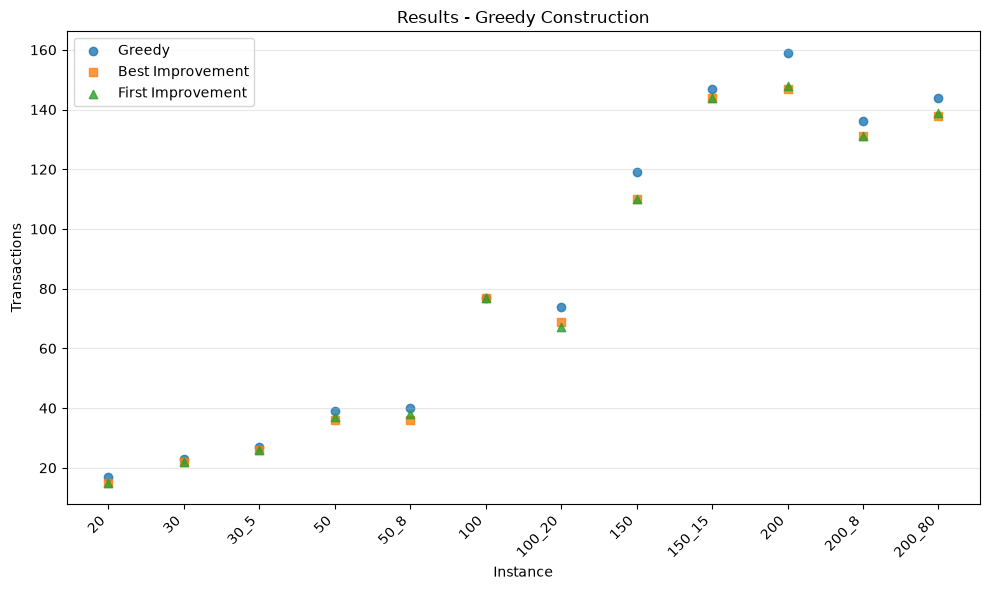

In [26]:
analysis.plot_results(
    rows,
    GREEDY_FITNESS,
    title='Results - Greedy Construction',
    y_label='Transactions',
    format_instance=short_name,
)

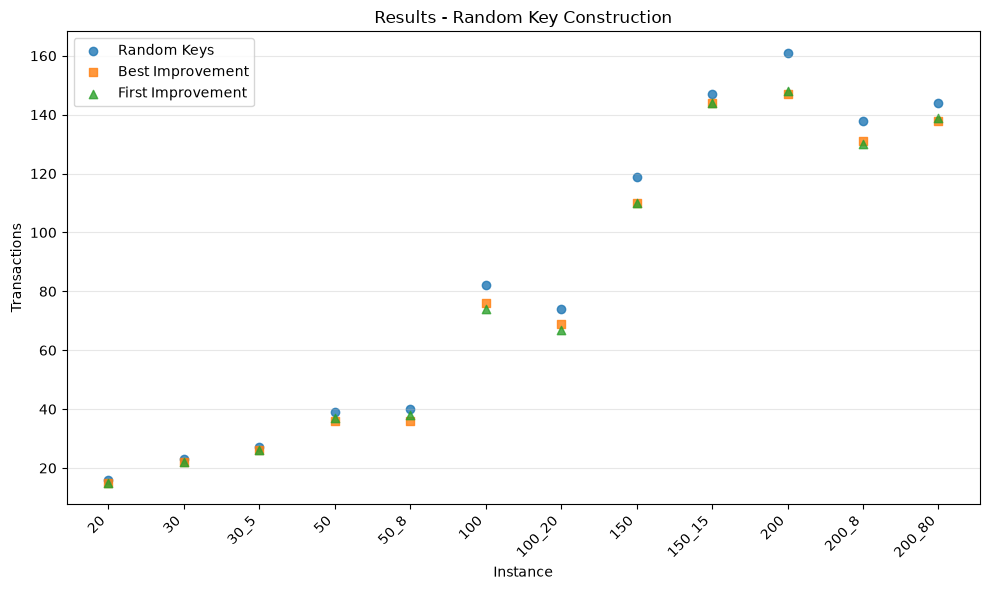

In [27]:
analysis.plot_results(
    rows,
    RANDOM_KEY_FITNESS,
    title='Results - Random Key Construction',
    y_label='Transactions',
    format_instance=short_name,
)

## Tabela de resultados

Uma linha por instância ($I$), com o valor da função objetivo ($sol$), o tempo de execução em
segundos ($t(s)$) e, para as buscas locais, o número de iterações do laço mais externo
($N_{It}$). Em cada linha, o melhor $sol$ entre os quatro algoritmos de busca local aparece em
negrito.

In [28]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

table = analysis.results_table(rows, format_instance=short_name)

analysis.highlight_best(table)